# XGBoost Embedding Baseline Model

This notebook builds an XGBoost baseline model for classifying which social media platform a post belongs to using `all-MiniLM-L6-v2` sentence embeddings.

## Goals
- load the final train, validation, test splits processed and saved from the create_datasets notebook
- encode post text with `all-MiniLM-L6-v2` sentence embeddings
- train an XGBoost classifier for multiclass platform prediction
- explicitly exclude non-text metadata features
- use GPU for embeddings and XGBoost training
- evaluate performance on validation and test sets


In [1]:
%pip install polars pyarrow pandas matplotlib scikit-learn scipy xgboost sentence-transformers torch

Note: you may need to restart the kernel to use updated packages.


In [14]:
from pathlib import Path
from time import perf_counter

import re
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import xgboost as xgb

from IPython.display import display
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)

polars.config.Config

## Paths

In [3]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "train_210k.parquet"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "val_45k.parquet"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "test_45k.parquet"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(TRAIN_PATH, TRAIN_PATH.exists())
print(VAL_PATH, VAL_PATH.exists())
print(TEST_PATH, TEST_PATH.exists())

/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/train_210k.parquet True
/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/val_45k.parquet True
/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/test_45k.parquet True


## Load train, validation, test data

In [4]:
train_df = pl.read_parquet(TRAIN_PATH)
val_df = pl.read_parquet(VAL_PATH)
test_df = pl.read_parquet(TEST_PATH)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(209987, 18) (44997, 18) (44998, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],f64,f64,…,i8,str,f64,str,f64,f64,str
"""hackernews""","""34593357""","""TheCowboy""","""The idea that tendencies for e…",2023-01-31 05:07:08,null,null,…,1,"""2023-01""",0.0,null,null,null,"""34592394"""
"""hackernews""","""45704131""","""senordevnyc""","""The actual quote is “make some…",2025-10-25 10:21:45,null,null,…,10,"""2025-10""",0.0,null,null,null,"""45704110"""
"""hackernews""","""41076936""","""enriquto""","""> the way it was made callable…",2024-07-26 04:48:48,null,null,…,7,"""2024-07""",0.0,null,null,null,"""41074451"""
"""reddit""","""t3_1fzrjm3""","""sanaloyuncu""","""Hangisini izlemeliyim? Edebiya…",2024-10-09 00:00:00,null,null,…,10,"""2024-10""",1.0,"""liseliler""",1.0,1.0,null
"""hackernews""","""47058341""","""robinwhg""","""But there already is cheaper c…",2026-02-18 02:40:55,null,null,…,2,"""2026-02""",0.0,null,null,null,"""47056458"""


## Quick class balance checks

In [5]:
print(train_df.group_by("platform").len().sort("platform"))
print(val_df.group_by("platform").len().sort("platform"))
print(test_df.group_by("platform").len().sort("platform"))

shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 69988 │
│ reddit     ┆ 69999 │
│ twitter    ┆ 70000 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 14997 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 14998 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘


## Feature policy

This notebook uses only the post text.

We explicitly do not use features like created_at, year, month, year_month, post_id, author, community, likes, retweets, replies, quotes, score, parent_id, or other metadata because they might encode platform-specific artifacts instead of classifying from the language of the post itself.

## Change to pandas for modeling

In [6]:
train_pdf = train_df.to_pandas()
val_pdf = val_df.to_pandas()
test_pdf = test_df.to_pandas()

print(train_pdf.columns.tolist())

['platform', 'post_id', 'author', 'text', 'created_at', 'likes', 'retweets', 'replies', 'quotes', 'text_len', 'year', 'month', 'year_month', 'score', 'community', 'num_comments', 'upvote_ratio', 'parent_id']


## Check GPU setup

This notebook expects CUDA to be available for both sentence embeddings and XGBoost training.

In [7]:
print("Torch version:", torch.__version__)
print("CUDA available in torch:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

xgb_build_info = xgb.build_info()
print("XGBoost version:", xgb.__version__)
print("XGBoost CUDA enabled:", bool(xgb_build_info.get("USE_CUDA", False)))

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available to PyTorch. Embedding generation would fall back to CPU.")

if not bool(xgb_build_info.get("USE_CUDA", False)):
    raise RuntimeError("This XGBoost build does not report CUDA support. GPU training will not be used.")

GPU_NAME = torch.cuda.get_device_name(0)
print("Using GPU:", GPU_NAME)

Torch version: 2.11.0+cu130
CUDA available in torch: True
CUDA device count: 1
XGBoost version: 3.2.0
XGBoost CUDA enabled: True
Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## Encode text with `all-MiniLM-L6-v2`

In [8]:
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DEVICE = "cuda"
BATCH_SIZE = 256

X_train_text = train_pdf["text"].astype(str).tolist()
X_val_text = val_pdf["text"].astype(str).tolist()
X_test_text = test_pdf["text"].astype(str).tolist()

print("Loading embedding model...")
t0 = perf_counter()
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=EMBEDDING_DEVICE)
t1 = perf_counter()
print(f"Embedding model loaded in {t1 - t0:.2f} seconds")
print("Embedding device:", embedding_model.device)

print("Encoding train text...")
t0 = perf_counter()
X_train_embed = embedding_model.encode(
    X_train_text,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
t1 = perf_counter()
print(f"Train embeddings done in {t1 - t0:.2f} seconds")

print("Encoding validation text...")
t0 = perf_counter()
X_val_embed = embedding_model.encode(
    X_val_text,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
t1 = perf_counter()
print(f"Validation embeddings done in {t1 - t0:.2f} seconds")

print("Encoding test text...")
t0 = perf_counter()
X_test_embed = embedding_model.encode(
    X_test_text,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
t1 = perf_counter()
print(f"Test embeddings done in {t1 - t0:.2f} seconds")

print("Embedding shapes:", X_train_embed.shape, X_val_embed.shape, X_test_embed.shape)

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded in 1.31 seconds
Embedding device: cuda:0
Encoding train text...


Batches:   0%|          | 0/821 [00:00<?, ?it/s]

Train embeddings done in 160.05 seconds
Encoding validation text...


Batches:   0%|          | 0/176 [00:00<?, ?it/s]

Validation embeddings done in 34.07 seconds
Encoding test text...


Batches:   0%|          | 0/176 [00:00<?, ?it/s]

Test embeddings done in 34.60 seconds
Embedding shapes: (209987, 384) (44997, 384) (44998, 384)


## Encode labels for XGBoost

In [9]:
y_train = train_pdf["platform"]
y_val = val_pdf["platform"]
y_test = test_pdf["platform"]

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['hackernews' 'reddit' 'twitter']


## Train XGBoost and evaluate

In [10]:
t0 = perf_counter()

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_embed,
    y_train_encoded,
    eval_set=[(X_val_embed, y_val_encoded)],
    verbose=False,
)

t1 = perf_counter()
print(f"Finished training in {t1 - t0:.2f} seconds")
print("Configured device:", xgb_model.get_xgb_params().get("device"))

val_pred_encoded = xgb_model.predict(X_val_embed)
test_pred_encoded = xgb_model.predict(X_test_embed)

val_pred = label_encoder.inverse_transform(val_pred_encoded)
test_pred = label_encoder.inverse_transform(test_pred_encoded)

val_accuracy = accuracy_score(y_val, val_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Validation accuracy:", val_accuracy)
print(classification_report(y_val, val_pred))

print("Test accuracy:", test_accuracy)
print(classification_report(y_test, test_pred))

Finished training in 54.43 seconds
Configured device: cuda


/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/.venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [16:47:48] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Validation accuracy: 0.8899482187701402
              precision    recall  f1-score   support

  hackernews       0.87      0.92      0.89     14997
      reddit       0.89      0.87      0.88     15000
     twitter       0.92      0.88      0.90     15000

    accuracy                           0.89     44997
   macro avg       0.89      0.89      0.89     44997
weighted avg       0.89      0.89      0.89     44997

Test accuracy: 0.8919951997866572
              precision    recall  f1-score   support

  hackernews       0.87      0.93      0.90     14998
      reddit       0.90      0.87      0.88     15000
     twitter       0.91      0.88      0.90     15000

    accuracy                           0.89     44998
   macro avg       0.89      0.89      0.89     44998
weighted avg       0.89      0.89      0.89     44998



## Confusion matrix on the test set

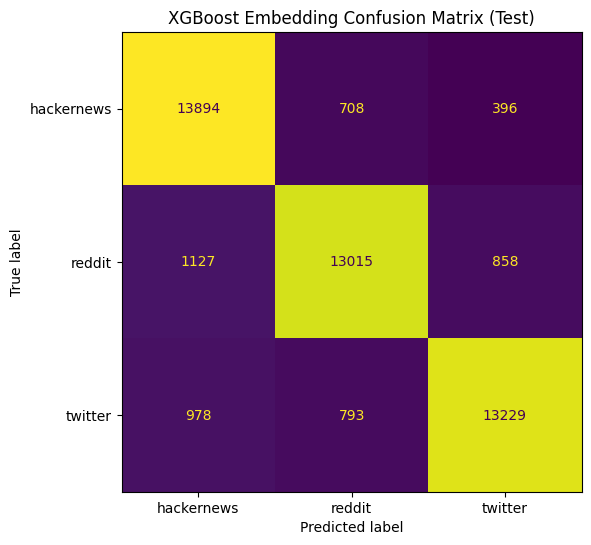

In [11]:
labels = list(label_encoder.classes_)

cm = confusion_matrix(y_test, test_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("XGBoost Embedding Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "xgboost_embedding_confusion_matrix.png", dpi=150)
plt.show()

## Most important embedding dimensions

These raw dimensions are still useful as a technical summary of which latent coordinates XGBoost split on most often, but they are not directly human-readable in the same way as TF-IDF terms or engineered text features.

In [12]:
importance_df = pd.DataFrame({
    "embedding_dim": range(X_train_embed.shape[1]),
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.head(20)

,embedding_dim,importance
250,250,0.051720
11,11,0.031319
176,176,0.027196
223,223,0.019844
224,224,0.019253
319,319,0.015557
142,142,0.015166
99,99,0.014436
221,221,0.012060
294,294,0.012029


## Example-based interpretation of top embedding dimensions

Since MiniLM embedding dimensions are latent features, the most honest way to interpret them is by looking at example posts that score very high or very low on each important dimension. This gives us a qualitative sense of the kinds of language patterns each dimension may be capturing without pretending that a raw embedding coordinate has a simple semantic label.

In [16]:
TOP_DIMS_TO_INTERPRET = 5
EXAMPLES_PER_SIDE = 3

train_example_df = train_pdf[["platform", "text"]].reset_index(drop=True).copy()

def clean_text_for_display(text: str) -> str:
    text = str(text).replace("\n", " ").strip()
    text = re.sub(r"\s+", " ", text)
    return text

def dimension_example_table(dim: int, n_examples: int = EXAMPLES_PER_SIDE) -> pd.DataFrame:
    values = X_train_embed[:, dim]
    high_idx = np.argsort(values)[-n_examples:][::-1]
    low_idx = np.argsort(values)[:n_examples]

    rows = []
    for direction, idxs in [("highest", high_idx), ("lowest", low_idx)]:
        for idx in idxs:
            rows.append({
                "dimension": dim,
                "direction": direction,
                "value": float(values[idx]),
                "platform": train_example_df.iloc[idx]["platform"],
                "text_example": clean_text_for_display(train_example_df.iloc[idx]["text"]),
            })

    return pd.DataFrame(rows)

top_dims = importance_df.head(TOP_DIMS_TO_INTERPRET)["embedding_dim"].tolist()

for dim in top_dims:
    dim_importance = importance_df.loc[importance_df["embedding_dim"] == dim, "importance"].iloc[0]
    print(f"\nEmbedding dimension {dim} | importance={dim_importance:.6f}")
    with pd.option_context("display.max_colwidth", None):
        display(dimension_example_table(dim))


Embedding dimension 250 | importance=0.051720


,dimension,direction,value,platform,text_example
0,250,highest,0.268829,reddit,"Instagram: ""¥$: The Vultures Experience. RUN UP MY POST. @rory_mitch203 None"
1,250,highest,0.258527,twitter,@DKlarations @davewolfusa @TheFavoritist @NASASpaceflight @ChrisG_NSF and to the AWESOME editor who pulled the video together!
2,250,highest,0.251255,twitter,Looking forward to the match @SUFC_tweets tonight with our guests from #littlehelper
3,250,lowest,-0.252174,reddit,"Why are there so many boulders in certain places I don’t understand why some mountains or other hilly areas will have excessive amounts of boulders but others won’t, in some places it seems like it’s an entire hill is made up of boulders. I would love to know why this is"
4,250,lowest,-0.242158,hackernews,"The demand side became pretty proficient regarding load shedding as well, making literally millions off of it."
5,250,lowest,-0.240736,hackernews,"In the Boston area many of the nearby towns are what I call ""urban suburbs"". Very family friendly, many single- or two-family homes, but also very walkable and many shops throughout the town. I'm talking about towns such as Brookline, Cambridge and Arlington. They are really nice towns to live in and in very high demand."



Embedding dimension 11 | importance=0.031319


,dimension,direction,value,platform,text_example
0,11,highest,0.264749,hackernews,"Yep if you want to make it more attractive don't break the browser for anyone trying to read your blog. Page Up/Down did nothing, there was no indication on how to navigate this page. I didn't read it."
1,11,highest,0.236429,hackernews,The market for used pre-2010 physical books will be huge. Personally I've stopped buying online books because of this kind of shenanigans and reverting back to having local music and movies for similar reasons. The idea that some remote working technocrats can change words of a book while I'm reading it just creeps me out.
2,11,highest,0.234883,hackernews,"If anyone's using Firefox it'll mess with everyone's performance. They're working on it, should be okay in the next month or so."
3,11,lowest,-0.240438,reddit,I Made Myself Sound Like A Darkin ( Rhaast's Race ) None
4,11,lowest,-0.236251,reddit,(Kik: UsernameDotCom69) Who’s ready to fall in love with a Kpop idol? | catfish None
5,11,lowest,-0.232689,reddit,"[EUW] Tier II jungler looking for a team to join My preferred role is jungle, I can still also play toplane and support if need be ( I can be a flexpick) my jungle mains are: Nunu, Skarner, Rammus and Warwick. ​ My summoner name is: Witlof Man ​ I dont flame and Im pretty chill overall"



Embedding dimension 176 | importance=0.027196


,dimension,direction,value,platform,text_example
0,176,highest,0.303086,hackernews,"From talking to Anton, it seems like GitHub integration is next up on the TODO list. Any feedback on whether you'd find that useful and how you think it should be done would be really appreciated."
1,176,highest,0.270384,twitter,"@ericamou signing copies for subscribers, pre-orders and website orders❤️ https://t.co/oGscNQaUTf"
2,176,highest,0.260175,twitter,His Excellency President @CyrilRamaphosa arriving at the Sefako Makgatho Presidential Guesthouse in Tshwane to receive #LettersofCredence from Heads of Mission-Designate #BetterAfricaBetterWorld 🌍 https://t.co/mU83iyzFgv
3,176,lowest,-0.250758,reddit,"Question about clear times Hey Hunters! I've noticed that quite a lot of you, when comparing the power of weapons, talk about clear times. Specifically how long it takes you to hunt down and kill/capture a large monster. I've seen a lot of talk saying that ""in order to get comparable clear times...don't use X weapon or use X weapon and armor sets"". I saw earlier about someone in G Rank complaining that they felt their weapon was under powered because they killed at G Rank monster in around 8 mins compared to the 4 mins it takes them with a different weapon. Why are shorter times, to the point of absurdity, the standard? Shouldn't we be more interested in having good hunts and fun fights? Maybe it's because I'm High Rank and I'm still finding new and tougher fights but I just don't see the point that of hunting something and killing it in under the amount of time that it takes to warm up a hot pocket. Just doesn't sound fun to me"
4,176,lowest,-0.248330,reddit,"PVP - Is just me or this skills are broken? First of all, i'm a noob in terms on pvp, i'm just starting with it, but i noticed that many of my deaths came always from the same 2 skills: overload light attacks and cristalshards. They are hitting beetwen 10-18k, ranged attacks that can almost one-shoot me (i'm around 20-21k hp) without much i can do dosn't seems like a proper mechanic. I heard that bows don't do that much damage to reward meele combat that is more ""risky"", but with this things one-shooting people at range, that argument don't have too much sense."
5,176,lowest,-0.237194,reddit,Can you handle it? None



Embedding dimension 223 | importance=0.019844


,dimension,direction,value,platform,text_example
0,223,highest,1.814682e-32,hackernews,wow cool!!!!!!!!!!!!!!!!!!!!!!! :0
1,223,highest,1.483488e-32,reddit,"Economic Political Compass So I've seen a bunch of posts on this sub quibbling about definitions so I thought I might try my hand at a solution: Using an Economic Compass that deals with who owns the economy or the means of production\*. The format for this compass only works on PC. Sorry. (Clarification and examples at the bottom) ........................**Authoritarian**........................ ...................................||................................... ...................................||................................... **Planned\_\_\_\_\_\_\_\_\_\_\_\_\_||\_\_\_\_\_\_\_\_\_\_\_\_\_\_\_Market** ...................................||.................................. ...................................||.................................. ..........................**Democratic**.......................... \*These definitions can be separate from the government organization in market economies. **My opinion, and therefore fact for what falls in each zone:** Authoritarian/Market: United States, Russia Pre-Ukraine invasion. This is Traditional Capitalism, where companies sell and buy resources and are either controlled by a boss, board, or non-employee stockholders. Authoritarian/Planned: Soviet Union, Pre-Colombian Inca, Maoist China. Sometimes called democratic centralism, this economic structure seeing an autocrat or an unelected party control the means of production according to multiyear plans. Democratic/Planned: UK's NHS, Cuba. These examples are a bit of stretch, as there aren't really many good examples a purely planned economy coexisting with a democratic government. Cuba is probably the best example of this model as most of its industries are nationalized and there is democratic involvement in the government (although there are limits on press & political freedom). Democratic/Market: Worker Coops, Tito's Yugoslavia, Hunter Gatherer Societies. This organizational structure sees workers in control of their means of production to buy and sell what they produce. This can exist through democratic control of businesses or individual production. Sorry for the horrible quality of the compass, this sub won't let me post pictures and it formats wrong with spaces, if anyone can post it more competently please do it."
2,223,highest,1.092257e-32,twitter,wow!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
3,223,lowest,-3.796831e-32,twitter,@RHGSIG @karina_filusch @computerspinnt @ICS_AG @netalexx @dani_stoffers @SuVuK @der_fisch001 @SteveJRitter @linuxkumpel @ASYSinghuber @Cultcoders @guidodeckstein @ArneBrandneu @aixzellent Die gibt es bestimmt in der nächsten Ausgabe des @informatikradar Magazins 😎
4,223,lowest,-3.636443e-32,twitter,@Mieke35735862 @MriaHajzer @lizBeth_Hineni @Gianlui91580067 @Tzipor336 @Ruthtgn69 @TruthWins4ever @LehiRed @james_anderssen @esp_anet @cemoimonica @zeque66 @NYCREMilton @shlomomeirisra3 @YaelSed1 @Helenhun20 @JankeHansenM @AlanZionist @reilluminati @LaurentTS56 @Esther28007 @Nelby37482058 @adelioalves3 @olgatorres540 @Wp7xtPXs0EaLPTn @Smalou1 @EvaDuranRamos @HeatherPlonski1 @coinabs @LenGrunstein @DSDloveyou Trust and stay positive Dear Mieke⚘️ Know that All things are possible when you believe 🌴💚 what your think in your mind tells you what will come. G'D's Shalom🕊 be with you 🙏☘️💛🕊 https://t.co/fmsG11kkQu
5,223,lowest,-3.425661e-32,twitter,@AndiFrankfurt @wfritz56 @PStter @mabagus @Don_Slivovic @alex13wetter @C7_black @Nic2012 @TscheijPieh @DerVatta_ @EintrachtEmma @RealdealOk @whatsnexteu @23oliver01 @AsiFinanz Traust du dich nicht



Embedding dimension 224 | importance=0.019253


,dimension,direction,value,platform,text_example
0,224,highest,0.218133,reddit,"HELP: Rega Elicit MK5 + KEF R3 Meta Hello, how are you? I’m looking to buy an integrated amp to be paired with my KEF R3 Meta Speakers. I really like the Rega Elicit MK5, but since the speakers are 4 ohm, I’m weary of the warning that comes in the amp’s user manual: “intended for use with 4-16 ohm speakers. Sustained used into speakers of less than 8 ohm could make the unit run warmer than normal”. Any advice on how this pairing would work in the long run? I never listen for extended periods of time and never blast full volume. Option B for me would be the Yamaha AS-1200 for the KEF. Thanks in advance!"
1,224,highest,0.208572,reddit,"Laundry I’m almost out of clean clothes, where/can I do laundry in the dorm? I’m a freshman in Carlyle."
2,224,highest,0.207315,twitter,@ohnahji Getting my school outfit ready!
3,224,lowest,-0.249706,hackernews,Looks like the objectivists downvoted you. Such is the nature of Hacker News!
4,224,lowest,-0.237909,hackernews,">...Heck, most people on Hackers News don’t even have an actual business. >The subject matter of the post drove businesses with real money to our site. ...from Hacker News? Anyone else find this rather contradictory?"
5,224,lowest,-0.230471,hackernews,"It's a classic example of someone who hasn't had to deal with ""hard"" statistics thinking that just drawing a trendline (and dismissing biases out-of-hand) is all that statistics is. The author is right that Chrome has a massive share, but everyone knows that. Any analysis more specific than that requires more than just overplotting exponentials on a graph."


The examples suggest that the XGBoost model is picking up on a mix of platform-specific surface conventions and broader discourse style. Dimension 250 looks strongly associated with short, promotional, or socially tagged posts: its high-value examples contain direct `@mentions`, hashtags, or callout-style wording, while its low-value examples are longer explanatory posts from Reddit and Hacker News. Dimension 11 separates more discussion-oriented Hacker News style from more title-like or community-post style Reddit text: the high end contains argumentative or reflective prose, while the low end contains recruitment, fandom, or self-presentation posts.

Dimension 176 seems to capture a contrast between short announcement-style posts and longer question-heavy Reddit discussions. Its high end includes concise update or event language, often with links or mentions, while its low end contains longer advice-seeking or complaint-style Reddit posts. Dimension 224 appears to separate conversational help-seeking or casual social text from more analytical Hacker News commentary: the high end includes requests for advice and lightweight everyday updates, while the low end includes critical, argumentative, or meta-discussion text about Hacker News itself.

Dimension 223 is harder to interpret cleanly. The values are extremely close to zero, and the example set mixes exaggerated punctuation, long Reddit exposition, and dense mention-heavy Twitter posts. That makes this dimension a good reminder that some latent coordinates may still be useful to the tree model without mapping neatly onto a single human-readable concept. Overall, these examples support the idea that the embedding-based model is not just learning one keyword at a time: it is using combinations of tone, post structure, mention/link density, and discussion style to separate the three platforms.